### Task 1 : Exploratory Data Analysis ( EDA ) 

# E-commerce Customer Analytics Project

## Objective:
This project analyzes customer purchasing behavior, sales patterns, customer segments, and customer sentiment to generate business insights.

## Tools Used:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

os.getcwd()

'C:\\Users\\asus'

In [5]:
import os

os.listdir(r"C:\Users\asus\onedrive\Documents")

['Abesit  group of institutions [Autosaved].pdf',
 'Abesit  group of institutions [Autosaved].pptm',
 'Abesit  group of institutions.pptm',
 'ayanika.jpg',
 'buss.jpg',
 'Custom Office Templates',
 'DATA FORGE .pdf',
 'DATA FORGE .pptx',
 'desktop.ini',
 'Document.docx',
 'Downloads - Shortcut.lnk',
 'ecommerce_customer_behavior_5000.csv.xlsx',
 'game of codes.pptx',
 'GRAPHICS.docx',
 'GRAPHICS1.docx',
 'My Tableau Repository',
 'myphoto.html',
 'myssc.jpeg',
 'pstm.jpg',
 'PYTHON QUIZ QUESTIONS.docx',
 'Q_Rcode.docx',
 'table.html',
 'table.txt',
 'TECH TRACK - Copy.pptx',
 'TECH TRACK [Autosaved].pptx',
 'TECH TRACK.pptx',
 'treasurehunt2..docx',
 'treasurehunt2~.docx',
 'WORKFLOW.pptx']

In [7]:
import os

file_path = r"C:\Users\asus\onedrive\Documents\ecommerce_customer_behavior_5000.csv.xlsx"

print(os.path.exists(file_path))

True


In [10]:
import os

file_path = r"C:\Users\asus\onedrive\Documents\ecommerce_customer_behavior_5000.csv.xlsx"

print(os.path.getsize(file_path))

289077


In [11]:
import mimetypes

print(mimetypes.guess_type(r"C:\Users\asus\onedrive\Documents\ecommerce_customer_behavior_5000.csv.xlsx"))


('application/vnd.openxmlformats-officedocument.spreadsheetml.sheet', None)


# 1. Dataset Loading

The dataset contains customer transaction details including customer demographics, product categories, payment methods, order values, delivery time, ratings, returns, and order dates.

In [1]:
import pandas as pd

file_path = r"C:\Users\asus\onedrive\Documents\ecommerce_customer_behavior_5000.csv.xlsx"

df = pd.read_excel(file_path, engine="openpyxl")

df.head()


,order_id,customer_age,customer_gender,product_category,payment_method,order_value_usd,delivery_time_days,customer_rating,returned,order_date
0,1,37,Other,Home & Living,Wallet,1366.60,10,2.3,No,2022-01-01
1,2,41,Female,Fashion,Cash on Delivery,1175.89,6,1.8,Yes,2022-01-02
2,3,30,Other,Sports,Debit Card,1283.97,7,3.2,No,2022-01-03
3,4,58,Female,Electronics,Credit Card,1245.76,14,3.8,No,2022-01-04
4,5,59,Other,Fashion,Cash on Delivery,1411.06,7,3.2,No,2022-01-05


# 2. Data Understanding

Initial analysis was performed to understand dataset structure, columns, data types, and statistical properties.

In [2]:
df.shape

(5000, 10)

In [3]:
df.columns

Index(['order_id', 'customer_age', 'customer_gender', 'product_category',
       'payment_method', 'order_value_usd', 'delivery_time_days',
       'customer_rating', 'returned', 'order_date'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            5000 non-null   int64         
 1   customer_age        5000 non-null   int64         
 2   customer_gender     5000 non-null   str           
 3   product_category    5000 non-null   str           
 4   payment_method      5000 non-null   str           
 5   order_value_usd     5000 non-null   float64       
 6   delivery_time_days  5000 non-null   int64         
 7   customer_rating     5000 non-null   float64       
 8   returned            5000 non-null   str           
 9   order_date          5000 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(2), int64(3), str(4)
memory usage: 390.8 KB


In [5]:
df.describe()

,order_id,customer_age,order_value_usd,delivery_time_days,customer_rating,order_date
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000
mean,2500.500000,43.263400,749.672238,7.47300,3.015720,2028-11-04 12:00:00
min,1.000000,18.000000,5.570000,1.00000,1.000000,2022-01-01 00:00:00
25%,1250.750000,30.000000,367.087500,4.00000,2.000000,2025-06-03 18:00:00
50%,2500.500000,43.000000,760.285000,7.00000,3.000000,2028-11-04 12:00:00
75%,3750.250000,56.000000,1120.752500,11.00000,4.000000,2032-04-07 06:00:00
max,5000.000000,69.000000,1499.370000,14.00000,5.000000,2035-09-09 00:00:00
std,1443.520003,15.000847,430.370938,4.03293,1.148516,NaN


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

order_id              0
customer_age          0
customer_gender       0
product_category      0
payment_method        0
order_value_usd       0
delivery_time_days    0
customer_rating       0
returned              0
order_date            0
dtype: int64

In [8]:
df['product_category'].value_counts()

product_category
Beauty           853
Fashion          851
Sports           851
Groceries        837
Home & Living    811
Electronics      797
Name: count, dtype: int64

# 3. Exploratory Data Analysis (EDA)

EDA was performed to identify patterns, trends, customer behavior, and relationships between different variables.

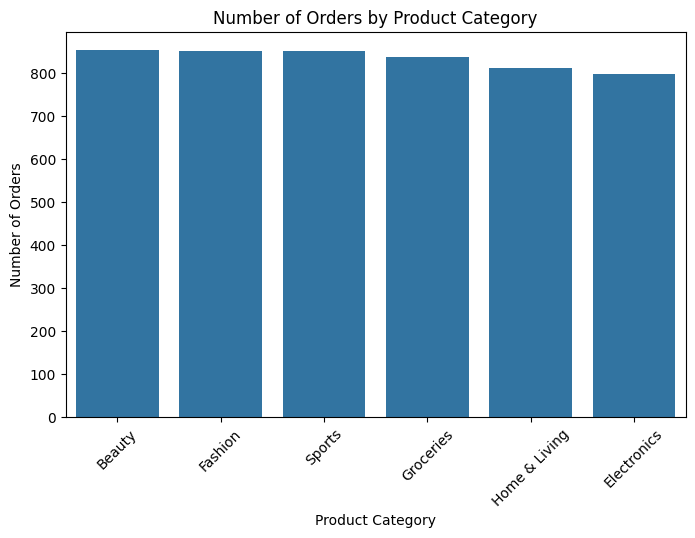

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='product_category',
    order=df['product_category'].value_counts().index
)

plt.title("Number of Orders by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

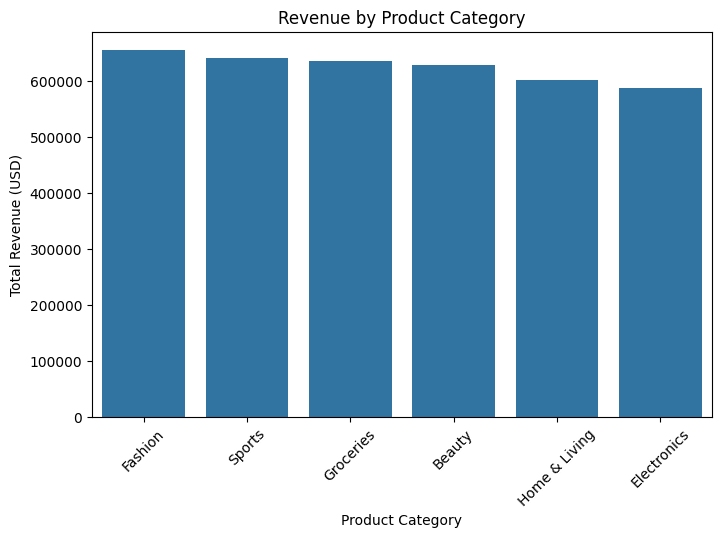

In [10]:
category_revenue = df.groupby('product_category')['order_value_usd'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue (USD)")

plt.xticks(rotation=45)

plt.show()

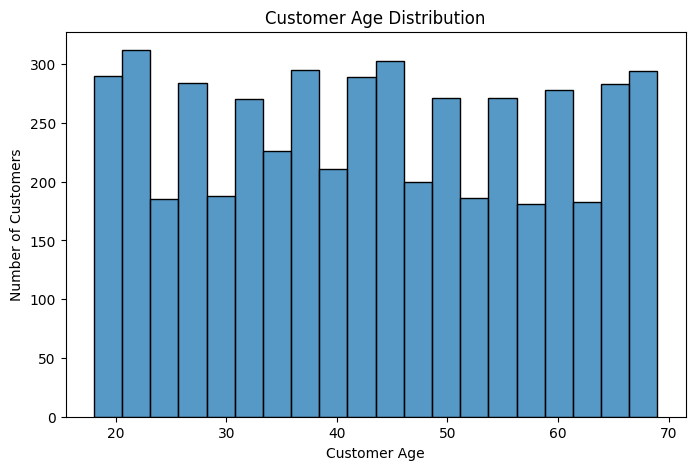

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='customer_age',
    bins=20
)

plt.title("Customer Age Distribution")
plt.xlabel("Customer Age")
plt.ylabel("Number of Customers")

plt.show()

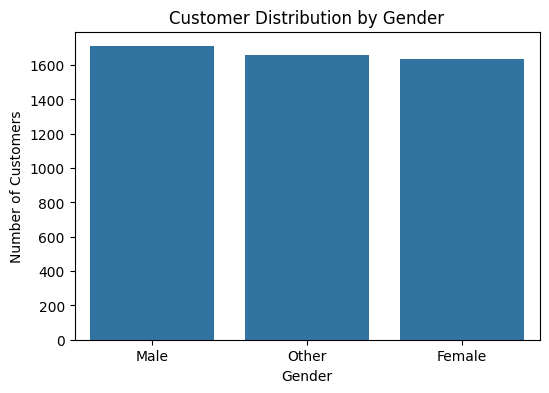

In [12]:
gender_count = df['customer_gender'].value_counts()

plt.figure(figsize=(6,4))

sns.barplot(
    x=gender_count.index,
    y=gender_count.values
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

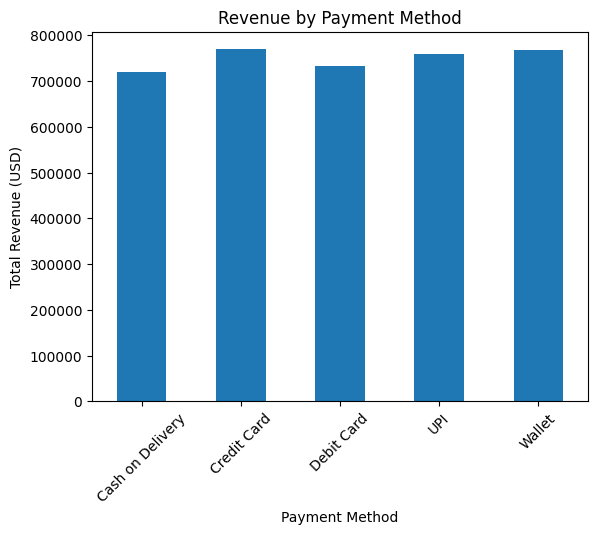

In [13]:
payment_revenue = df.groupby('payment_method')['order_value_usd'].sum()

payment_revenue.plot(kind='bar')

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=45)

plt.show()

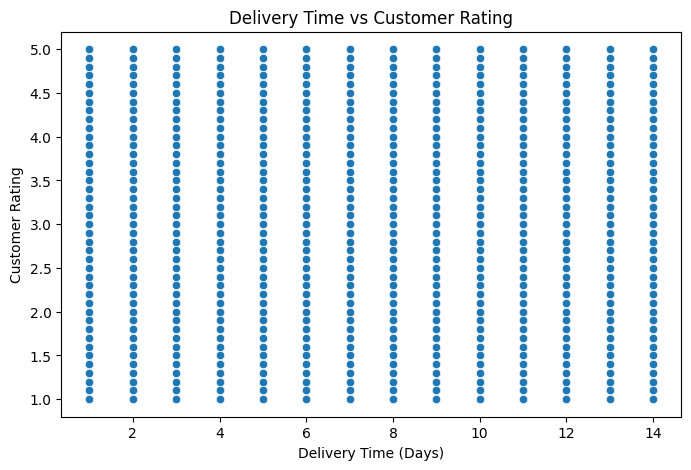

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="delivery_time_days",
    y="customer_rating"
)

plt.title("Delivery Time vs Customer Rating")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Customer Rating")

plt.show()

In [15]:
return_analysis = df.groupby('product_category')['returned'].value_counts()

return_analysis

product_category  returned
Beauty            Yes         446
                  No          407
Electronics       No          404
                  Yes         393
Fashion           No          440
                  Yes         411
Groceries         Yes         430
                  No          407
Home & Living     Yes         414
                  No          397
Sports            Yes         431
                  No          420
Name: count, dtype: int64

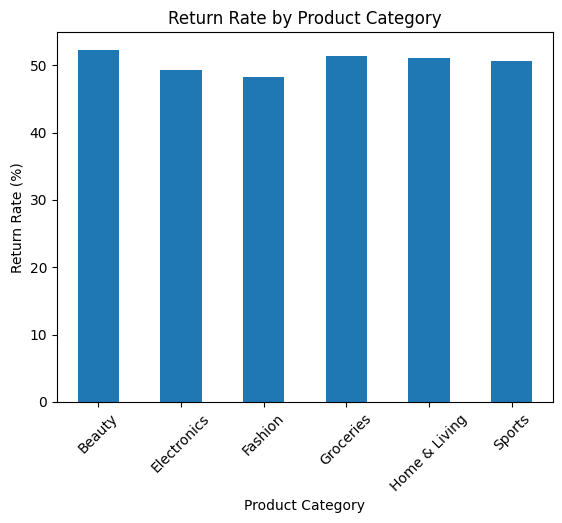

In [16]:
return_rate = df.groupby('product_category')['returned'].apply(
    lambda x: (x == 'Yes').mean()*100
)

return_rate.plot(kind='bar')

plt.title("Return Rate by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)

plt.show()

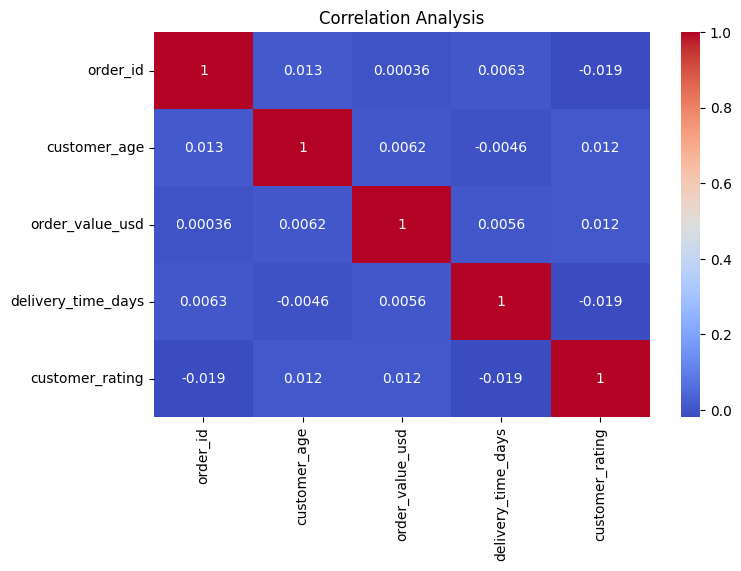

In [17]:
plt.figure(figsize=(8,5))

sns.heatmap(df.corr(numeric_only=True), 
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Analysis")

plt.show()

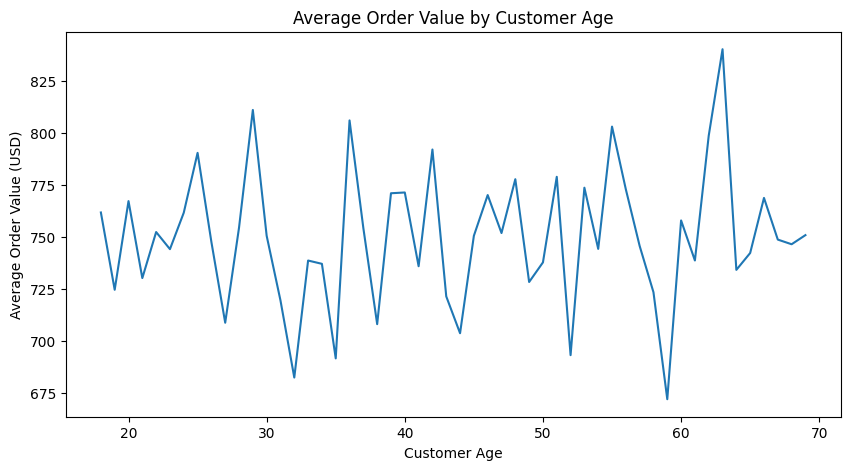

In [18]:
customer_value = df.groupby("customer_age")["order_value_usd"].mean()

plt.figure(figsize=(10,5))

customer_value.plot()

plt.title("Average Order Value by Customer Age")
plt.xlabel("Customer Age")
plt.ylabel("Average Order Value (USD)")

plt.show()

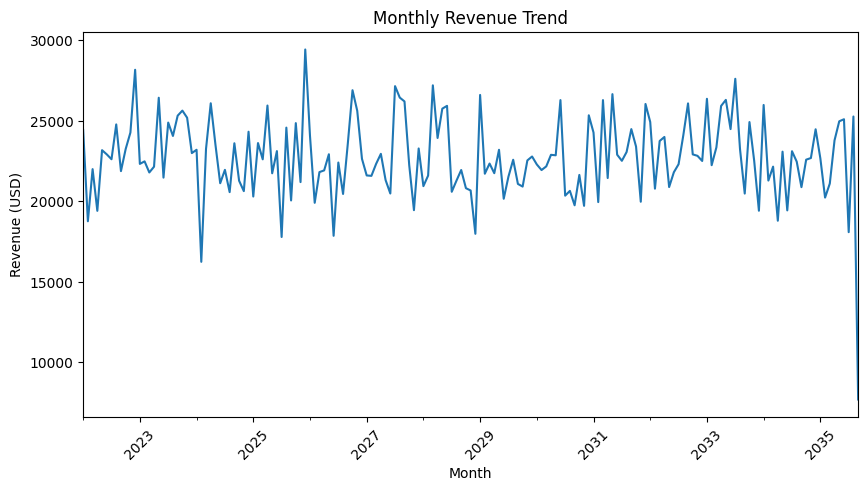

In [19]:
df['order_date'] = pd.to_datetime(df['order_date'])

monthly_sales = df.groupby(
    df['order_date'].dt.to_period('M')
)['order_value_usd'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (USD)")

plt.xticks(rotation=45)

plt.show()

# Key Insights from Exploratory Data Analysis (EDA)

- Product categories have a balanced order distribution, with Beauty, Fashion, and Sports receiving slightly higher orders.

- Fashion category generates the highest revenue, followed by Sports and Groceries.

- Customer age ranges from 18 to 69 years, showing a diverse customer base across different age groups.

- Gender distribution is almost balanced, indicating equal participation from different customer groups.

- Revenue contribution is distributed evenly across payment methods, with digital payment options showing strong usage.

- Customer ratings range between 1 and 5, but delivery time does not show a strong impact on customer satisfaction.

- Return percentage is similar across all product categories, with no category showing unusually high returns.

- Average order value remains relatively stable across different age groups, suggesting age does not strongly affect spending behaviour.

- Monthly revenue shows fluctuations over time but remains within a consistent range without major seasonal patterns.

- Correlation analysis shows weak relationships between numerical variables such as age, delivery time, rating, and order value.

- Overall, customer purchasing behaviour appears to be influenced by multiple factors rather than a single variable.

### Task 2 : customer Segmentation

Customers were grouped based on purchasing behavior to identify different customer segments and understand customer value.

In [21]:
# Creating customer segments based on order value

df['customer_segment'] = pd.cut(
    df['order_value_usd'],
    bins=[0,500,1000,1500],
    labels=['Low Value Customer','Medium Value Customer','High Value Customer']
)

df.head()

,order_id,customer_age,customer_gender,product_category,payment_method,order_value_usd,delivery_time_days,customer_rating,returned,order_date,customer_segment
0,1,37,Other,Home & Living,Wallet,1366.60,10,2.3,No,2022-01-01,High Value Customer
1,2,41,Female,Fashion,Cash on Delivery,1175.89,6,1.8,Yes,2022-01-02,High Value Customer
2,3,30,Other,Sports,Debit Card,1283.97,7,3.2,No,2022-01-03,High Value Customer
3,4,58,Female,Electronics,Credit Card,1245.76,14,3.8,No,2022-01-04,High Value Customer
4,5,59,Other,Fashion,Cash on Delivery,1411.06,7,3.2,No,2022-01-05,High Value Customer


In [24]:
segment_count = df['customer_segment'].value_counts()

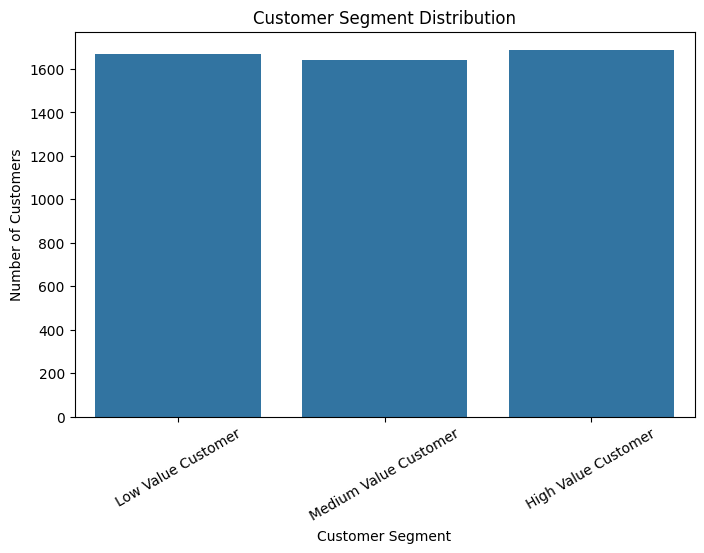

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_count.index,
    y=segment_count.values
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.show()

In [26]:
segment_revenue = df.groupby('customer_segment')['order_value_usd'].sum()

segment_revenue

customer_segment
Low Value Customer        417441.81
Medium Value Customer    1237470.23
High Value Customer      2093449.15
Name: order_value_usd, dtype: float64

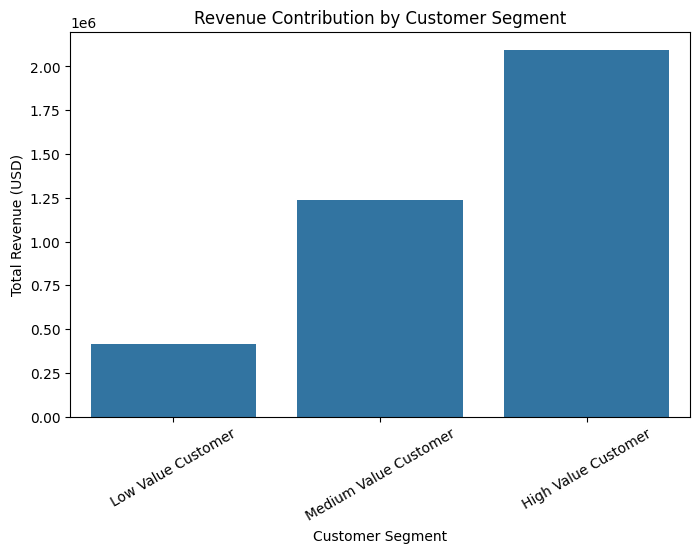

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_revenue.index,
    y=segment_revenue.values
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue (USD)")

plt.xticks(rotation=30)

plt.show()

# Customer Segmentation Insights

- Customers were segmented into Low, Medium, and High value groups based on order value.

- High value customers represent the most important customer group because they contribute higher revenue per transaction.

- Medium value customers form the potential growth segment that can be targeted with marketing strategies.

- Low value customers contribute smaller purchases but represent opportunities for upselling and retention.

- Customer segmentation helps businesses design personalized strategies for different customer groups.

### Task 3 : Sentiment Analysis

In [28]:
def sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['customer_rating'].apply(sentiment)

df.head()

,order_id,customer_age,customer_gender,product_category,payment_method,order_value_usd,delivery_time_days,customer_rating,returned,order_date,customer_segment,sentiment
0,1,37,Other,Home & Living,Wallet,1366.60,10,2.3,No,2022-01-01,High Value Customer,Negative
1,2,41,Female,Fashion,Cash on Delivery,1175.89,6,1.8,Yes,2022-01-02,High Value Customer,Negative
2,3,30,Other,Sports,Debit Card,1283.97,7,3.2,No,2022-01-03,High Value Customer,Negative
3,4,58,Female,Electronics,Credit Card,1245.76,14,3.8,No,2022-01-04,High Value Customer,Negative
4,5,59,Other,Fashion,Cash on Delivery,1411.06,7,3.2,No,2022-01-05,High Value Customer,Negative


In [29]:
sentiment_count = df['sentiment'].value_counts()

sentiment_count

sentiment
Negative    3536
Positive    1329
Neutral      135
Name: count, dtype: int64

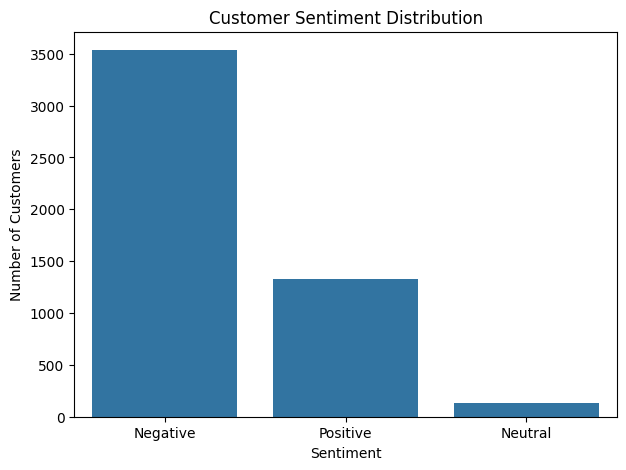

In [30]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=sentiment_count.index,
    y=sentiment_count.values
)

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Customers")

plt.show()

In [31]:
sentiment_category = pd.crosstab(
    df['product_category'],
    df['sentiment']
)

sentiment_category

sentiment,Negative,Neutral,Positive
product_category,,,
Beauty,600,21,232
Electronics,561,34,202
Fashion,578,25,248
Groceries,601,24,212
Home & Living,591,19,201
Sports,605,12,234


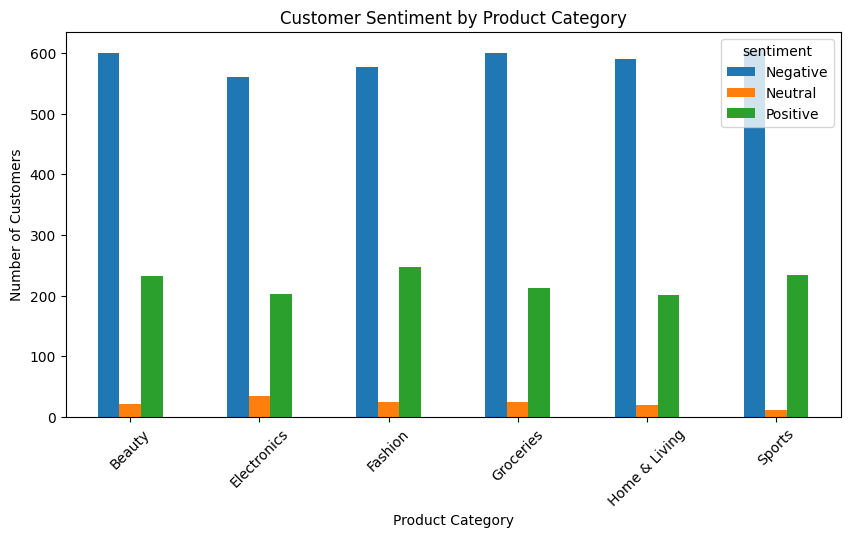

In [32]:
sentiment_category.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Customer Sentiment by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

Are customers who return products more likely to have negative experiences?

In [33]:
return_sentiment = pd.crosstab(
    df['returned'],
    df['sentiment']
)

return_sentiment

sentiment,Negative,Neutral,Positive
returned,,,
No,1764,71,640
Yes,1772,64,689


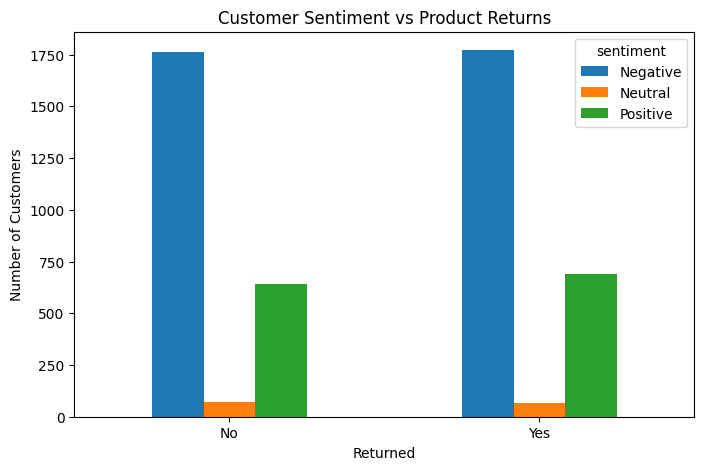

In [34]:
return_sentiment.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Customer Sentiment vs Product Returns")
plt.xlabel("Returned")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.show()

### Sentiment Analysis Insights:

* Sentiment analysis was performed to understand overall customer satisfaction levels using Positive, Neutral, and Negative sentiment categories.

* Negative sentiment was the most dominant category, indicating potential customer dissatisfaction and areas requiring improvement.

* Positive feedback was observed across all product categories, showing that customers also had satisfactory experiences.

* Fashion and Groceries categories showed comparatively higher positive sentiment, indicating better customer response.

* Electronics and Home & Living categories showed comparatively lower positive sentiment, suggesting possible improvement opportunities.

* Returned and non-returned products showed similar sentiment patterns, indicating that negative experiences are not caused only by product returns.

* Customer dissatisfaction may be influenced by factors such as product quality, delivery experience, or expectation mismatch.

* Sentiment analysis helps identify customer pain points and supports better decisions for improving customer experience and retention.


#  Key Insights and Recommendations

The analysis provides insights into customer behavior, sales trends, customer segments, and satisfaction levels to support business decision-making.